<a href="https://colab.research.google.com/github/sun-mengwei/dtb-colab-experiments/blob/elliptic-pde/dtb_elliptic_rotated_anisotropic_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DTB--Ritz with rotated anisotropic diffusion

We solve $-\nabla\cdot(A\nabla u)=f$ with $A=Q\,\mathrm{diag}(1,0.02)Q^T$ and a $45^\circ$ rotation. The manufactured reference $u_*=\cos(3\pi x/2)\cos(\pi y/2)$ makes the off-diagonal diffusion terms active.

In [1]:
# Repository setup for a fresh Colab runtime.
import os,subprocess
from pathlib import Path
if Path('DTB_elliptic_utils.py').exists(): ROOT=Path.cwd()
else:
    ROOT=Path('/content/dtb-colab-experiments')
    if not ROOT.exists(): subprocess.run(['git','clone','-b','elliptic-pde','https://github.com/sun-mengwei/dtb-colab-experiments.git',str(ROOT)],check=True)
    os.chdir(ROOT)
print('repository:',ROOT)

repository: /content/dtb-colab-experiments


In [2]:
import math
import matplotlib.pyplot as plt
import numpy as np
import torch
from DTB_elliptic_utils import (MLP,armijo_update,direct_ritz_energy,envelope_gradient,expand_direction,flatten_parameters,make_box_trial,manufactured_forcing,matrix_ritz_energy,predict_tangent,relative_l2_error,sample_box,select_parameter_indices,solve_tangent_ritz,summarize_history)

torch.set_default_dtype(torch.float64); torch.manual_seed(4)
DIM,VOLUME=2,4.0; N_TRAIN,N_VALID=1024,4096
OUTER_STEPS,TANGENT_DIM=40,16
RIDGE_RELATIVE,INITIAL_STEP=1e-4,1.0
angle=math.pi/4
Q=torch.tensor([[math.cos(angle),-math.sin(angle)],[math.sin(angle),math.cos(angle)]])
A=Q@torch.diag(torch.tensor([1.0,0.02]))@Q.T
model=MLP(DIM,width=20,depth=2); theta,spec=flatten_parameters(model)
trial=make_box_trial(model,spec); indices=select_parameter_indices(theta.numel(),TANGENT_DIM,41)
x_train,x_valid=sample_box(N_TRAIN,DIM,42),sample_box(N_VALID,DIM,43)

In [3]:
def exact(x):
    return torch.cos(1.5*math.pi*x[...,0])*torch.cos(0.5*math.pi*x[...,1])
f_train=manufactured_forcing(exact,x_train,diffusion=A)
axis=torch.linspace(-1,1,81); xx,yy=torch.meshgrid(axis,axis,indexing='ij')
grid=torch.stack((xx.flatten(),yy.flatten()),dim=1)
print('diffusion matrix:\n',A)

diffusion matrix:
 tensor([[0.5100, 0.4900],
        [0.4900, 0.5100]])


## Runner: anisotropic stiffness assembly and envelope update

The plotted $F(\theta)$ is the unregularized empirical Ritz energy; the small ridge only stabilizes the inner linear solve.

In [4]:
history,snapshots=[],{}; snapshot_steps={0,OUTER_STEPS//2,OUTER_STEPS}
for step in range(OUTER_STEPS+1):
    solution,stiffness,load=solve_tangent_ritz(
        trial,theta,indices,x_train,f_train,VOLUME,diffusion=A,ridge_relative=RIDGE_RELATIVE)
    direction=expand_direction(solution.alpha,indices,theta.numel())
    history.append(dict(
        step=step,F_theta=float(matrix_ritz_energy(stiffness,load,solution.alpha)),
        relative_l2=relative_l2_error(trial,theta,direction,x_valid,exact),
        inner_residual=solution.relative_residual,alpha_norm=float(torch.linalg.norm(solution.alpha))))
    if step in snapshot_steps:
        snapshots[step]=predict_tangent(trial,theta,direction,grid).detach().reshape(81,81).numpy()
    if step==OUTER_STEPS: break
    gradient=envelope_gradient(trial,theta,direction,x_train,f_train,VOLUME,diffusion=A)
    fixed=lambda th: direct_ritz_energy(trial,th,direction.detach(),x_train,f_train,VOLUME,diffusion=A)
    theta,_=armijo_update(fixed,theta,gradient,initial_step=INITIAL_STEP)
summarize_history([history[0],history[len(history)//2],history[-1]])

step=  0  F(theta)=-5.621e+00  rel-L2=2.208e-01  inner-res=5.6e-15  ||alpha||=1.11e+02
step= 20  F(theta)=-5.667e+00  rel-L2=2.121e-01  inner-res=6.1e-15  ||alpha||=1.06e+02
step= 40  F(theta)=-5.706e+00  rel-L2=2.057e-01  inner-res=4.8e-15  ||alpha||=1.04e+02


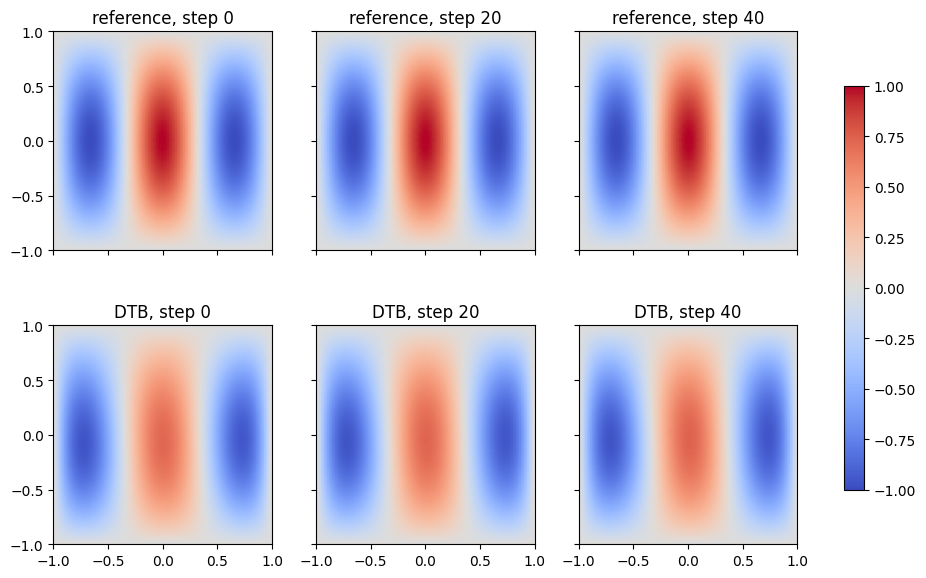

In [5]:
# Reference (top) and DTB (bottom) across outer-iteration time.
reference=exact(grid).reshape(81,81).numpy(); limit=float(np.max(np.abs(reference)))
fig,axes=plt.subplots(2,len(snapshots),figsize=(12,7),sharex=True,sharey=True)
for column,(step,field) in enumerate(snapshots.items()):
    for row,(values,label) in enumerate([(reference,'reference'),(field,'DTB')]):
        image=axes[row,column].imshow(values.T,origin='lower',extent=(-1,1,-1,1),cmap='coolwarm',vmin=-limit,vmax=limit)
        axes[row,column].set_title(f'{label}, step {step}')
fig.colorbar(image,ax=axes,shrink=.75); plt.show()

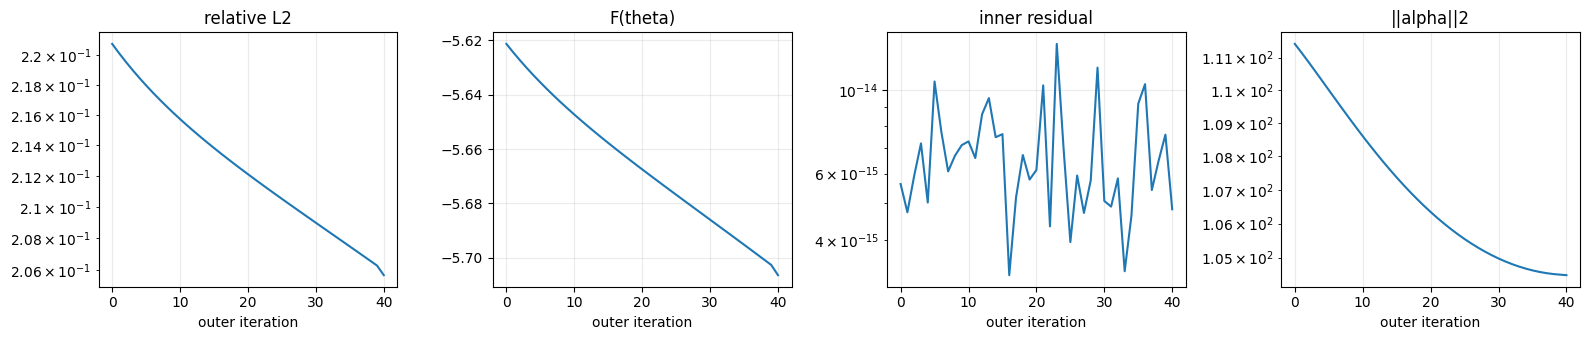

In [6]:
fig,axes=plt.subplots(1,4,figsize=(16,3.5)); steps=[r['step'] for r in history]
series=[('relative_l2','relative L2',True),('F_theta','F(theta)',False),('inner_residual','inner residual',True),('alpha_norm','||alpha||2',True)]
for ax,(key,title,logy) in zip(axes,series):
    ax.plot(steps,[r[key] for r in history]); ax.set(xlabel='outer iteration',title=title); ax.grid(alpha=.25)
    if logy: ax.set_yscale('log')
plt.tight_layout(); plt.show()